# Optical pumping in a magnetic field

This script checks the rotations in the OBEs by optically pumping with circular polarized
light along all three axes and seeing if it pumps to the appropriate spin state
along those axes.  It compares these to direct integration of the Schrodinger equation.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import jax.numpy as jnp
import pylcp_jax
from pylcp_jax.integration_tools_gpu import solve_ivp_dense
from pylcp_jax.common import spherical2cart

transform = False # Change the variable to transform OBEs into re/im components.

### Define the problem

In [2]:
# Which polarization do we want?
pol = +1

# First, create the laser beams:
laserBeams = {}
laserBeams['x']= pylcp_jax.laserBeams(
    [{'kvec': np.array([1., 0., 0.]), 'pol':pol, 'delta':0., 's':2.0}],
    beam_type=pylcp_jax.infinitePlaneWaveBeam
    )
laserBeams['y']= pylcp_jax.laserBeams(
    [{'kvec': np.array([0., 1., 0.]), 'pol':pol, 'delta':0., 's':2.0}],
    beam_type=pylcp_jax.infinitePlaneWaveBeam
    )
laserBeams['z']= pylcp_jax.laserBeams(
    [{'kvec': np.array([0., 0., 1.]), 'pol':pol, 'delta':0., 's':2.0}],
    beam_type=pylcp_jax.infinitePlaneWaveBeam
    )

# For making the Hamiltonian
E={}
for key in laserBeams:
    E[key] = laserBeams[key].cartesian_pol()[0]

# Then the magnetic field:
magField = lambda R: np.zeros(R.shape)
gF=1

# Hamiltonian for F=0->F=1
Hg, mugq, basis_g = pylcp_jax.hamiltonians.singleF(F=0, gF=gF, muB=1, return_basis=True)
He, mueq, basis_e = pylcp_jax.hamiltonians.singleF(F=1, gF=gF, muB=1, return_basis=True)
d_q = pylcp_jax.hamiltonians.dqij_two_bare_hyperfine(0, 1)
hamiltonian = pylcp_jax.hamiltonian(Hg, He, mugq, mueq, d_q)
laserBeams['x'].total_electric_field(np.array([0., 0., 0.]), 0.)
obe = {}

basis = np.concatenate((basis_g, basis_e))

### Let's start with no magnetic field

We will do this by constructing the full Hamiltonian in three different ways, and makes sure they are all equal.  It then integrates the Schrodinger equation and then compares to the OBEs integrated without decays (should be equivalent).

True True
True True
True True


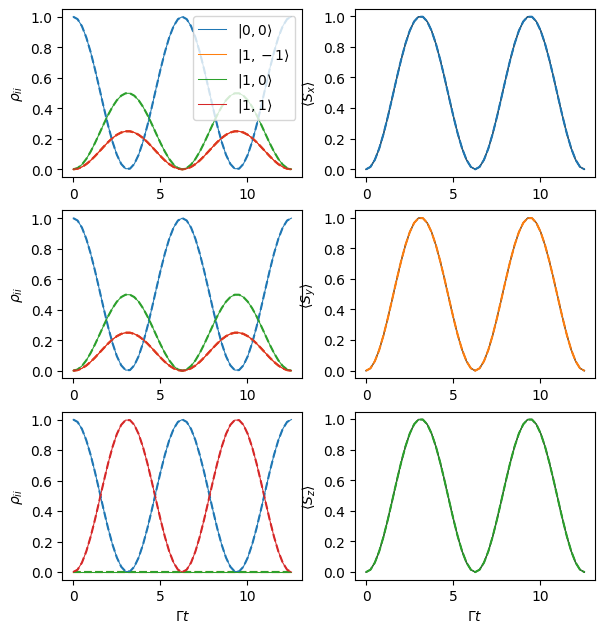

In [4]:
# Excited state spin observable.  The spin is not along the magnetic moment:
S_ex = -spherical2cart(mueq)/gF
S = np.zeros((3, hamiltonian.n, hamiltonian.n), dtype='complex128')
S[:, 1:, 1:] = S_ex

n_pts = 51
t_end = 4*np.pi

# Make a figure
fig, ax = plt.subplots(3, 2, figsize=(6.5, 2.5*2.75))
for ii, key in enumerate(laserBeams):
    ax[ii, 1].plot(np.linspace(0, t_end, n_pts),
                   pol*(1-np.cos(np.linspace(0, t_end, n_pts)))/2, 'k-',
                   linewidth=1)
    d = spherical2cart(d_q)
    H_sub = -0.5*np.tensordot(d, E[key], axes=(0, 0))

    H = np.zeros((4, 4)).astype('complex128')
    H[0, 1:] = H_sub
    H[1:, 0] = np.conjugate(H_sub)

    H_sub2 = np.zeros(d_q[0].shape).astype('complex128')
    for kk, q in enumerate(np.arange(-1, 2, 1)):
        H_sub2 -= 0.5*(-1.)**q*d_q[kk]*laserBeams[key].beam_vector[0].pol()[2-kk]

    H2 = np.zeros((4, 4)).astype('complex128')
    H2[0, 1:] = H_sub2
    H2[1:, 0] = np.conjugate(H_sub2)

    H3 = hamiltonian.return_full_H({'g->e': laserBeams[key].beam_vector[0].pol()},
                                   np.zeros((3,)).astype('complex128'))

    print(np.allclose(H, H2), np.allclose(H, H3))

    # Schrödinger equation via solve_ivp_dense
    H2_jnp = jnp.asarray(H2)
    def se_rhs(t, x, _H=H2_jnp):
        return -1j * _H @ x
    psi0 = jnp.zeros(4, dtype=jnp.complex128).at[0].set(1.)
    ts_SE, ys_SE = solve_ivp_dense(se_rhs, [0., t_end], psi0[None, :], n_points=n_pts)
    # ts_SE: (n_pts,)  ys_SE: (1, n_pts, 4)

    S_av = np.array([jnp.real(jnp.conj(ys_SE[0, jj, 1:]) @ S_ex[ii] @ ys_SE[0, jj, 1:])
                     for jj in range(n_pts)])

    for jj in range(4):
        ax[ii, 0].plot(np.array(ts_SE), np.abs(np.array(ys_SE[0, :, jj]))**2,
                       '--', color='C%d'%jj)

    ax[ii, 1].plot(np.array(ts_SE), S_av, '--', color='C%d'%ii)

    obe[key] = pylcp_jax.obe(laserBeams[key], magField, hamiltonian,
                         transform_into_re_im=transform)
    rho0 = np.zeros((16,))
    rho0[0] = 1  # Always start in the ground state.

    obe[key].ev_mat['decay'] = jnp.zeros_like(obe[key].ev_mat['decay'])  # Forcibly turn off decay
    obe[key].set_initial_rho(rho0)
    obe[key].evolve_density([0., t_end], n_points=n_pts)

    # Reconstruct sol.rho for observable/plotting
    n = obe[key].hamiltonian.n
    obe[key].sol.rho = obe[key]._obe__reshape_rho(obe[key].sol.y[0, :, :n**2].T)

    S_av = obe[key].observable(S[ii])

    for jj in range(4):
        ax[ii, 0].plot(np.array(obe[key].sol.t),
                       np.real(np.array(obe[key].sol.rho[jj, jj])),
                       linewidth=0.75, color='C%d'%jj,
                       label='$|%d,%d\\rangle$'%(basis[jj, 0], basis[jj, 1]))
    ax[ii, 0].set_ylabel('$\\rho_{ii}$')

    ax[ii, 1].plot(np.array(obe[key].sol.t), np.array(S_av),
                   color='C%d'%ii, linewidth=0.75)
    ax[ii, 1].set_ylabel('$\\langle S_%s\\rangle$'%key)

[ax[-1, jj].set_xlabel('$\\Gamma t$') for jj in range(2)]
ax[0, 0].legend()
fig.subplots_adjust(left=0.08, bottom=0.05, wspace=0.22)

Dashed curves are integration of the Hamiltonian through the Schrodinger equation, and the solid curves are the OBEs.

### Next, let's apply a magnetic field

And see if we can tune the lasers into
resonance.  This will check to make sure that we have the detunings right.

With $g_F>0$, the shift for $+m_F$ is upwards, requiring a blue-shift on the
lasers (or, equivalently, the Hamiltonian) to compensate.

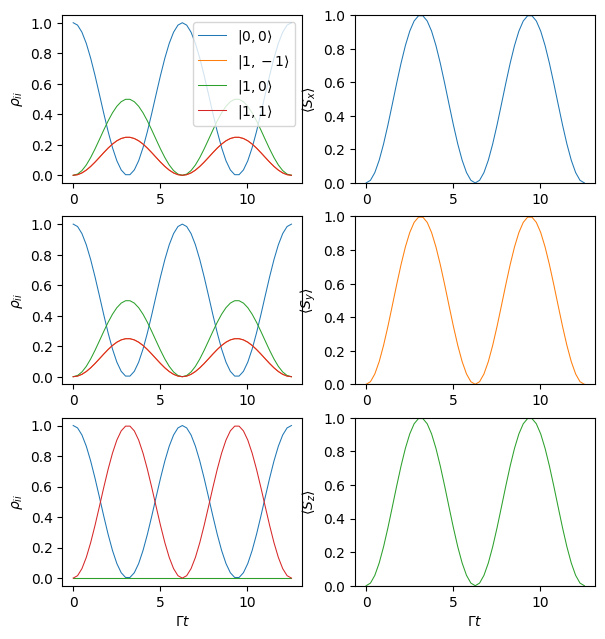

In [5]:
magField = {}
magField['x'] = lambda R: np.array([-1., 0., 0.])
magField['y'] = lambda R: np.array([0., -1., 0.])
magField['z'] = lambda R: np.array([0., 0., -1.])

pol=+1
laser_det=-0.5
ham_det=-0.5
laserBeams = {}
laserBeams['x']= pylcp_jax.laserBeams([
    {'kvec': np.array([1., 0., 0.]), 'pol':pol, 'delta':laser_det, 's':2.0}
    ])
laserBeams['y']= pylcp_jax.laserBeams([
    {'kvec': np.array([0., 1., 0.]), 'pol':pol, 'delta':laser_det, 's':2.0}
    ])
laserBeams['z']= pylcp_jax.laserBeams([
    {'kvec': np.array([0., 0., 1.]), 'pol':pol, 'delta':laser_det, 's':2.0}
    ])

hamiltonian = pylcp_jax.hamiltonian(Hg, He-ham_det*np.eye(3), mugq, mueq, d_q)

fig, ax = plt.subplots(3, 2, figsize=(6.5, 2.5*2.75))
for ii, key in enumerate(laserBeams):
    obe[key] = pylcp_jax.obe(laserBeams[key], magField[key], hamiltonian,
                         transform_into_re_im=transform)
    rho0 = np.zeros((16,))
    rho0[0] = 1  # Always start in the ground state.

    obe[key].ev_mat['decay'] = jnp.zeros_like(obe[key].ev_mat['decay'])  # Forcibly turn off decay
    obe[key].set_initial_rho(rho0)
    obe[key].evolve_density([0., t_end], n_points=n_pts)

    # Reconstruct sol.rho for observable/plotting
    n = obe[key].hamiltonian.n
    obe[key].sol.rho = obe[key]._obe__reshape_rho(obe[key].sol.y[0, :, :n**2].T)

    for jj in range(4):
        ax[ii, 0].plot(np.array(obe[key].sol.t),
                       np.real(np.array(obe[key].sol.rho[jj, jj])),
                       linewidth=0.75, color='C%d'%jj,
                       label='$|%d,%d\\rangle$'%(basis[jj, 0], basis[jj, 1]))
    ax[ii, 0].set_ylabel('$\\rho_{ii}$')

    S_av = obe[key].observable(S)

    ax[ii, 1].plot(np.array(obe[key].sol.t), np.array(S_av).T, linewidth=0.75)
    ax[ii, 1].set_ylabel('$\\langle S_%s\\rangle$'%key)
    ax[ii, 1].set_ylim((0, 1))

[ax[-1, jj].set_xlabel('$\\Gamma t$') for jj in range(2)]
ax[0, 0].legend()
fig.subplots_adjust(left=0.08, bottom=0.05, wspace=0.22)

### Finally, let's switch to some different polarization along $z$:

True True
True True


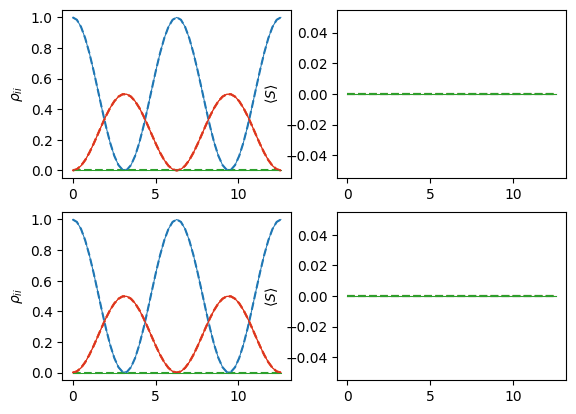

In [6]:
# Which polarization do we want?
pol = +1
ham_det = 0.

# First, create the laser beams:
laserBeams['$\\pi_x$']= pylcp_jax.laserBeams([
    {'kvec': np.array([0., 0., 1.]), 'pol':np.array([1., 0., 0.]),
     'pol_coord':'cartesian', 'delta':0., 's':2.0}
    ])
laserBeams['$\\pi_y$']= pylcp_jax.laserBeams([
    {'kvec': np.array([0., 0., 1.]), 'pol':np.array([0., 1., 0.]),
     'pol_coord':'cartesian', 'delta':0., 's':2.0}
    ])

hamiltonian = pylcp_jax.hamiltonian(Hg, He-ham_det*np.eye(3), mugq, mueq, d_q)
magField = lambda R: np.array([0., 0., 0.])

fig, ax = plt.subplots(2, 2, figsize=(6.5, 1.75*2.75))
for ii, key in enumerate(['$\\pi_x$', '$\\pi_y$']):
    d = spherical2cart(d_q)
    E = spherical2cart(laserBeams[key].beam_vector[0].pol())

    H_sub = -0.5*np.tensordot(d, E, axes=(0, 0))

    H = np.zeros((4, 4)).astype('complex128')
    H[0, 1:] = H_sub
    H[1:, 0] = np.conjugate(H_sub)

    H_sub2 = np.zeros(d_q[0].shape).astype('complex128')
    for kk, q in enumerate(np.arange(-1, 2, 1)):
        H_sub2 -= 0.5*(-1.)**q*d_q[kk]*laserBeams[key].beam_vector[0].pol()[2-kk]

    H2 = np.zeros((4, 4)).astype('complex128')
    H2[0, 1:] = H_sub2
    H2[1:, 0] = np.conjugate(H_sub2)

    H3 = hamiltonian.return_full_H({'g->e': laserBeams[key].beam_vector[0].pol()},
                                   np.zeros((3,)).astype('complex128'))

    print(np.allclose(H, H2), np.allclose(H, H3))

    # Schrödinger equation via solve_ivp_dense
    H_jnp = jnp.asarray(H)
    def se_rhs(t, x, _H=H_jnp):
        return -1j * _H @ x
    psi0 = jnp.zeros(4, dtype=jnp.complex128).at[0].set(1.)
    ts_SE, ys_SE = solve_ivp_dense(se_rhs, [0., t_end], psi0[None, :], n_points=n_pts)
    # ts_SE: (n_pts,)  ys_SE: (1, n_pts, 4)

    S_av = np.zeros((3, n_pts))
    for jj in range(3):
        S_av[jj] = np.array([jnp.real(jnp.conj(ys_SE[0, kk, 1:]) @ S_ex[jj] @ ys_SE[0, kk, 1:])
                              for kk in range(n_pts)])

    for jj in range(4):
        ax[ii, 0].plot(np.array(ts_SE), np.abs(np.array(ys_SE[0, :, jj]))**2,
                       '--', color='C%d'%jj)

    for jj in range(3):
        ax[ii, 1].plot(np.array(ts_SE), S_av[jj], '--', color='C%d'%jj)

    obe[key] = pylcp_jax.obe(laserBeams[key], magField, hamiltonian,
                         transform_into_re_im=transform)
    rho0 = np.zeros((16,))
    rho0[0] = 1  # Always start in the ground state.

    obe[key].ev_mat['decay'] = jnp.zeros_like(obe[key].ev_mat['decay'])  # Forcibly turn off decay
    obe[key].set_initial_rho(rho0)
    obe[key].evolve_density([0., t_end], n_points=n_pts)

    # Reconstruct sol.rho for observable/plotting
    n = obe[key].hamiltonian.n
    obe[key].sol.rho = obe[key]._obe__reshape_rho(obe[key].sol.y[0, :, :n**2].T)

    S_av = obe[key].observable(S)

    for jj in range(4):
        ax[ii, 0].plot(np.array(obe[key].sol.t),
                       np.real(np.array(obe[key].sol.rho[jj, jj])),
                       linewidth=0.75, color='C%d'%jj,
                       label='$|%d,%d\\rangle$'%(basis[jj, 0], basis[jj, 1]))
    ax[ii, 0].set_ylabel('$\\rho_{ii}$')

    for jj in range(3):
        ax[ii, 1].plot(np.array(obe[key].sol.t), np.array(S_av[jj]),
                       linewidth=0.75, color='C%d'%jj)
    ax[ii, 1].set_ylabel('$\\langle S\\rangle$')